In [4]:
import sys
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [5]:
import onep

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

In [6]:
# Define animals for each group
mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10',
             'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

In [7]:
#Grab your mice and take accepted traces - convert to numpy arrays within mouse_id variable names
for mouse_id in mouse_ids:
    try:
        traces = collection_fc.animals[mouse_id].accepted_traces.to_numpy()
        globals()[mouse_id] = traces[:3303, :]
        print(f"Created variable {mouse_id} with shape {globals()[mouse_id].shape}")
    except Exception as e:
        print(f"Error loading {mouse_id}: {e}")

Created variable astroF3 with shape (3303, 125)
Created variable astroF5 with shape (3303, 195)
Created variable astroF6 with shape (3303, 191)
Created variable astroF7 with shape (3303, 130)
Created variable astroF8 with shape (3303, 309)
Created variable astroF9 with shape (3303, 291)
Created variable astroF10 with shape (3303, 204)
Created variable astroM3 with shape (3303, 165)
Created variable astroM4 with shape (3303, 275)
Created variable astroM5 with shape (3303, 288)
Created variable astroM6 with shape (3303, 177)
Created variable astroM7 with shape (3303, 253)
Created variable astroM8 with shape (3303, 239)
Created variable astroM9 with shape (3303, 115)
Created variable astroM10 with shape (3303, 175)


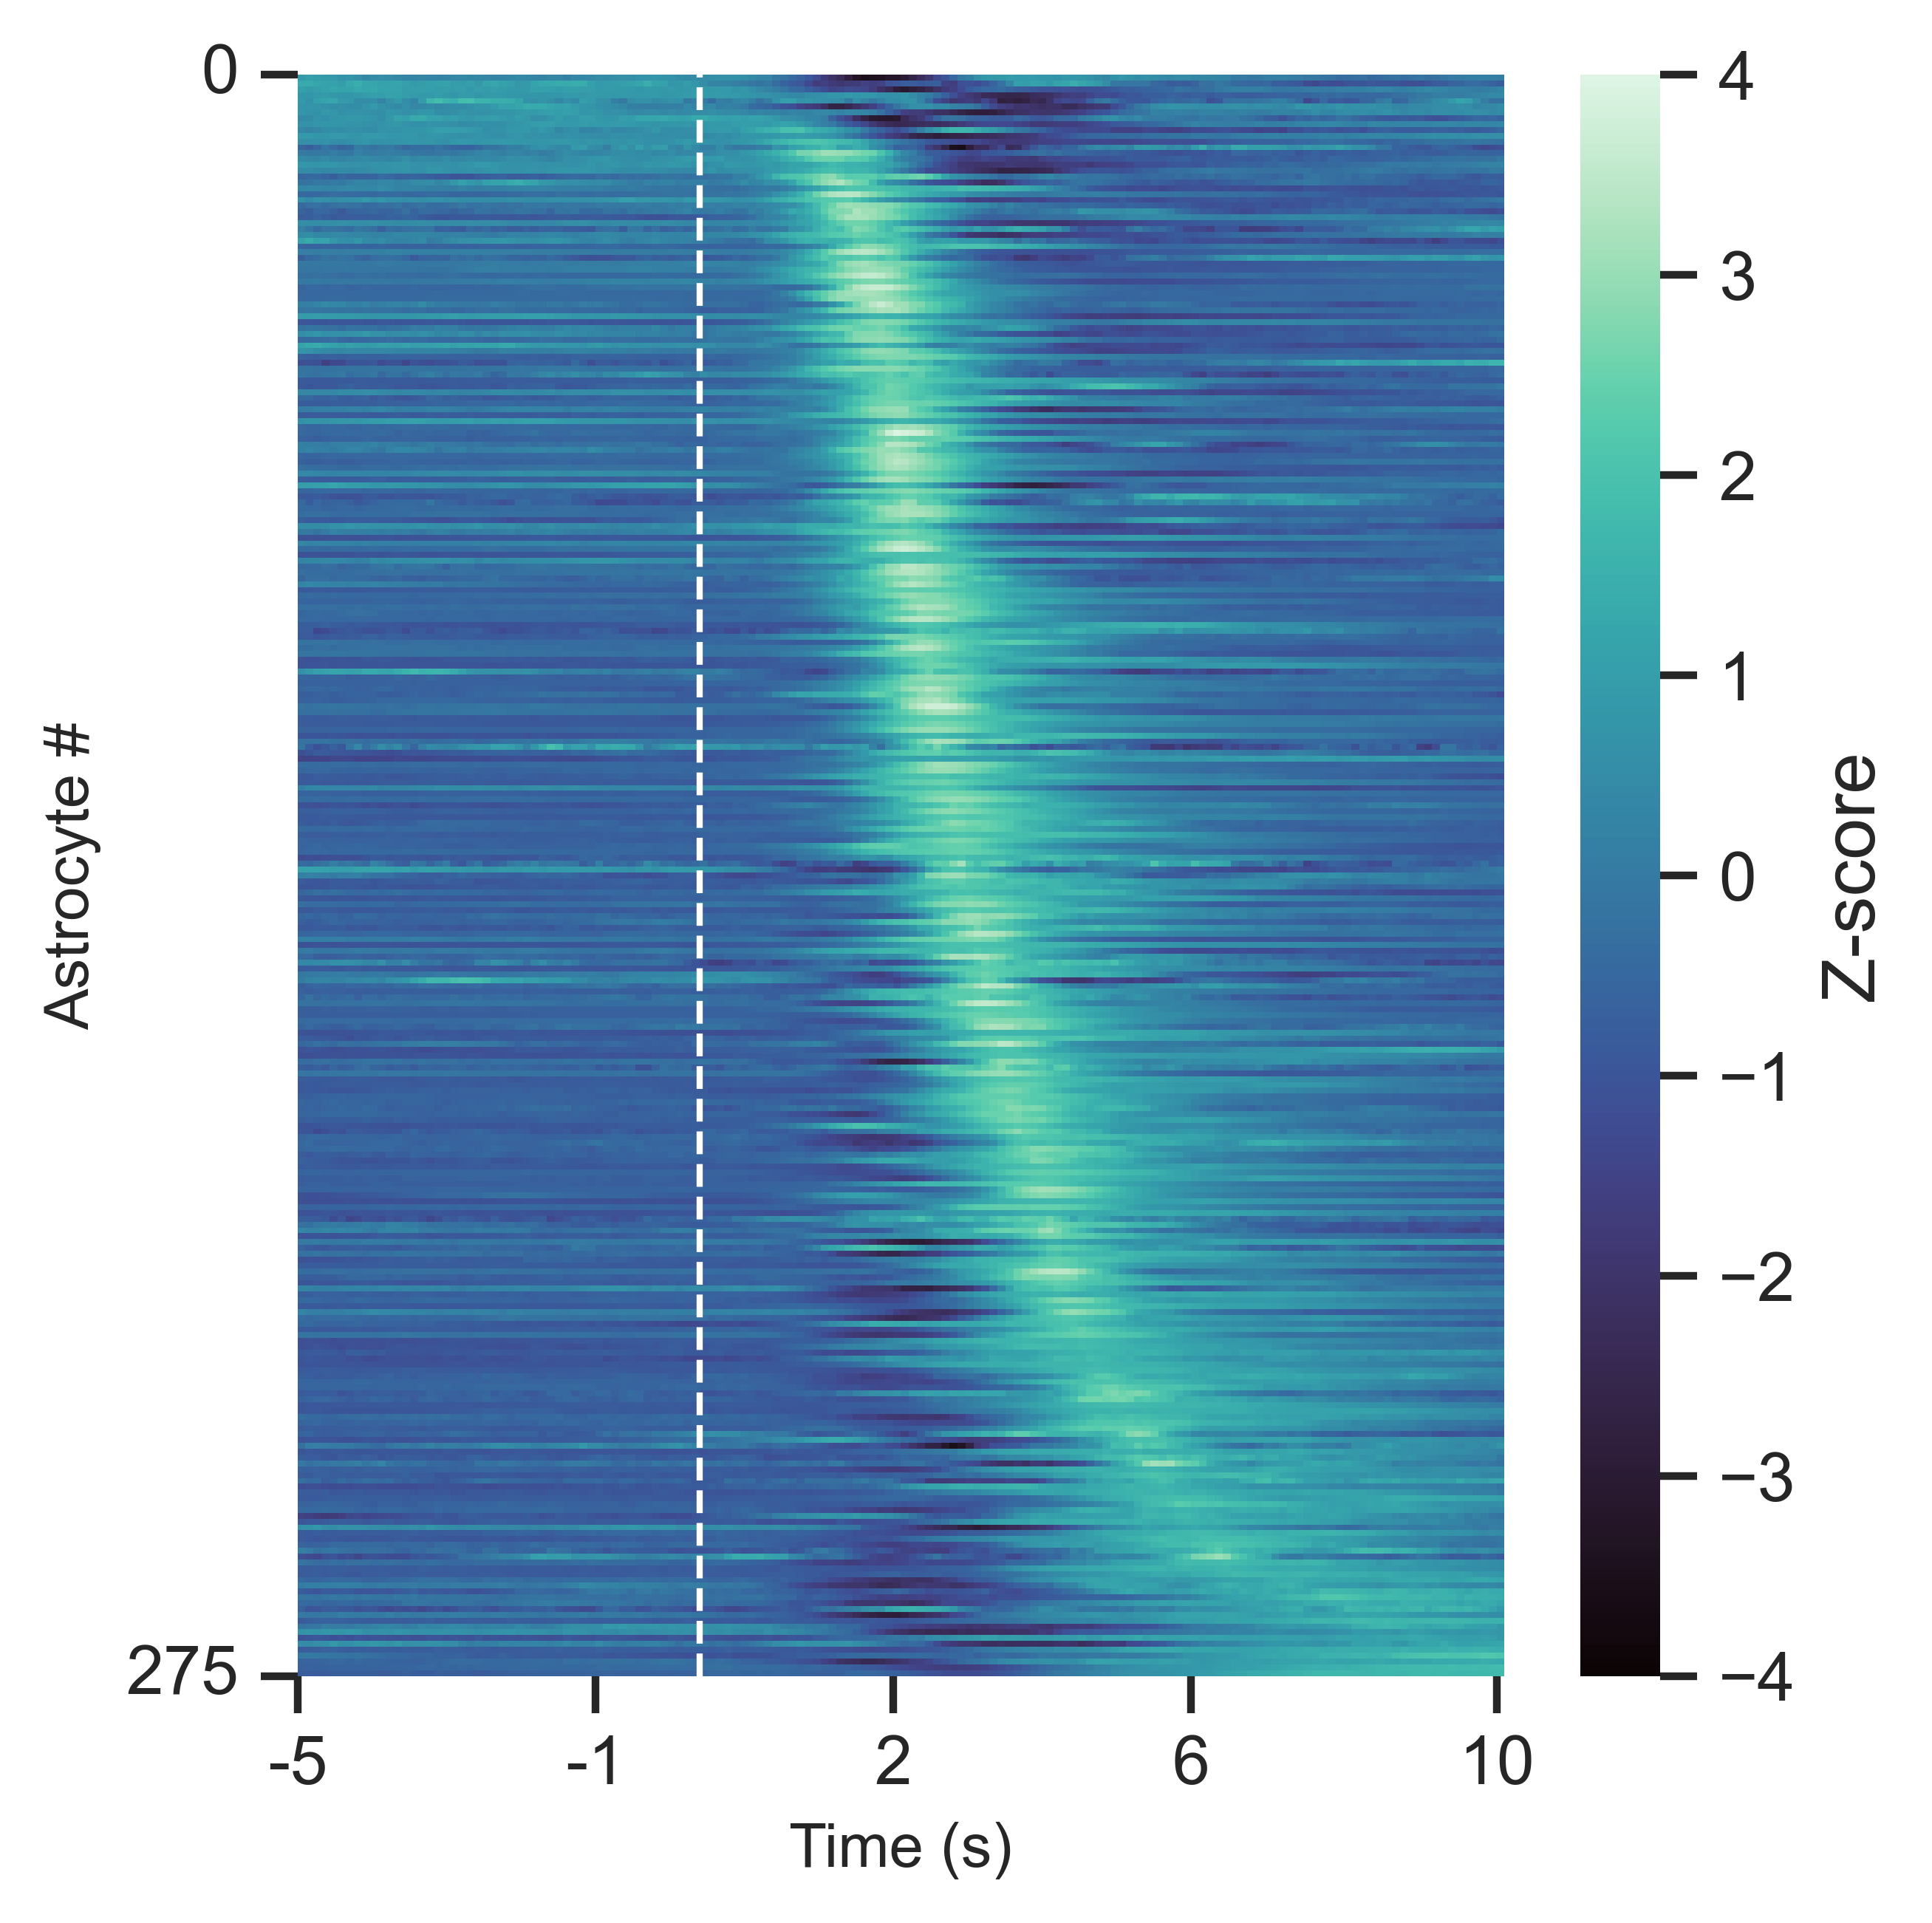

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def run_avg_event_heatmap(
    animal_id,
    traces,            # (T x N) or (N x T)
    timestamps,        # (T,) in seconds
    events,            # list of event times in seconds
    save_path_prefix=None,
    window=28,
    vmin=-4, vmax=4
):
    """
    Computes ETA for ALL given events (averaged), then plots ONE heatmap
    sorted by each cell's peak response time (argmax).

    Returns
    -------
    fig, ax, heatmap_path (or None if not saved)
    """
    # Ensure (N x T) for onep.*
    if traces.shape[0] == timestamps.shape[0]:
        data_for_eta = traces.T     # T x N -> N x T
    else:
        data_for_eta = traces       # already N x T

    # --- ETA averaged over all events ---
    eta_mean, eta_time = onep.eta_individual_cells(
        data_for_eta, timestamps, [list(events)], window=window
    )
    # eta_mean: (N_cells x T_eta), eta_time: (T_eta,)

    # Z-score per cell across time
    z = stats.zscore(eta_mean, axis=1, nan_policy='omit')
    z = np.nan_to_num(z, nan=0.0)

    # Sort rows by each cell’s argmax (if onep.maxsort exists, use it; else fallback)
    z_sorted, order = onep.maxsort(z)

    # --- Plot ---
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5), dpi=600)
    sns.set(style="ticks", font="Arial")

    hm = sns.heatmap(
        z_sorted, ax=ax, cmap='mako', vmin=vmin, vmax=vmax,
        cbar=True, cbar_kws={'label': 'Z-score'}, xticklabels=True, yticklabels=True, rasterized=True
    )

    # Label only first and last cell number on y-axis
    n_cells = z_sorted.shape[0]
    ax.set_yticks([0, n_cells])
    ax.set_yticklabels(['0', str(n_cells)], rotation=0)

    # X ticks as seconds
    T = z_sorted.shape[1]
    xticks = np.linspace(0, T-1, 5).astype(int)
    xticklabels = np.linspace(float(eta_time.min()), float(eta_time.max()), 5).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    # Mark event onset at 0 s if the ETA window straddles zero
    if (eta_time[0] < 0) and (eta_time[-1] > 0):
        zero_idx = np.argmin(np.abs(eta_time - 0))
        ax.axvline(zero_idx, linestyle='--', color='white', linewidth=1)

    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Astrocyte #', fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()

    out_path = None
    if save_path_prefix:
        out_path = f"{save_path_prefix}_avg_events_heatmap.svg"
        fig.savefig(out_path, dpi=600, bbox_inches='tight')

    return fig, ax, out_path

fig, ax, fp = run_avg_event_heatmap(
    animal_id='astroM4',
    traces=astroM4,  # shape T x N from your earlier loop
    timestamps=collection_fc.animals['astroM4'].Timestamps[:astroM4.shape[0]].to_numpy().squeeze(),
    events=[120, 180, 240, 300],   # all shocks
    window=10,
    save_path_prefix='/Users/suthardr/Desktop/Revision/',
    vmin=-4, vmax=4
)



In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def run_post_event_heatmap(
    animal_id,
    traces,            # (T x N) or (N x T)
    timestamps,        # (T,) in seconds
    events,            # list of event times in seconds
    save_path_prefix=None,
    window=15,         # seconds AFTER event onset
    vmin=-4, vmax=4
):
    """
    Compute average ΔF/F response after events (no pre-period) and plot a heatmap
    sorted by each cell’s peak (argmax).

    Returns
    -------
    fig, ax, save_path (or None)
    """
    # Ensure data is (N_cells x T)
    if traces.shape[0] == timestamps.shape[0]:
        data_for_eta = traces.T
    else:
        data_for_eta = traces

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(window * fs)
    time = np.linspace(0, window, n_points)

    # Interpolate per event
    def event_window(signal, e):
        t_win = np.linspace(e, e + window, n_points)
        interp = np.interp(t_win, timestamps, signal)
        return interp

    # Average ETA for each cell
    all_cells = []
    for sig in data_for_eta:
        event_traces = [event_window(sig, e) for e in events if e + window <= timestamps[-1]]
        if event_traces:
            all_cells.append(np.mean(event_traces, axis=0))
    eta_mean = np.array(all_cells)  # (N_cells x n_points)

    # Z-score per cell
    z = stats.zscore(eta_mean, axis=1, nan_policy='omit')
    z = np.nan_to_num(z, nan=0.0)

    # Sort by peak
    try:
        z_sorted, order = onep.maxsort(z)
    except Exception:
        order = np.argsort(np.argmax(z, axis=1))
        z_sorted = z[order]

    # --- Plot ---
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})
    fig, ax = plt.subplots(figsize=(3, 4.5), dpi=600)
    sns.set(style="ticks", font="Arial")

    sns.heatmap(
        z_sorted, ax=ax, cmap='mako', vmin=vmin, vmax=vmax,
        cbar=True, cbar_kws={'label': 'Z-score'}, xticklabels=True, yticklabels=False, rasterized=True
    )

    # X-axis in seconds
    T = z_sorted.shape[1]
    xticks = np.linspace(0, T - 1, 5).astype(int)
    xticklabels = np.linspace(0, window, 5).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    # Y-axis: only first & last cell
    n_cells = z_sorted.shape[0]
    ax.set_yticks([0, n_cells])
    ax.set_yticklabels(['1', str(n_cells)], rotation=0)

    ax.axvline(0, linestyle='--', color='white', linewidth=1)
    ax.set_xlabel('Time after event (s)', fontsize=10)
    ax.set_ylabel('Astrocyte #', fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()

    out_path = None
    if save_path_prefix:
        out_path = f"{save_path_prefix}_post_event_heatmap.svg"
        fig.savefig(out_path, dpi=600, bbox_inches='tight')

    return fig, ax, out_path


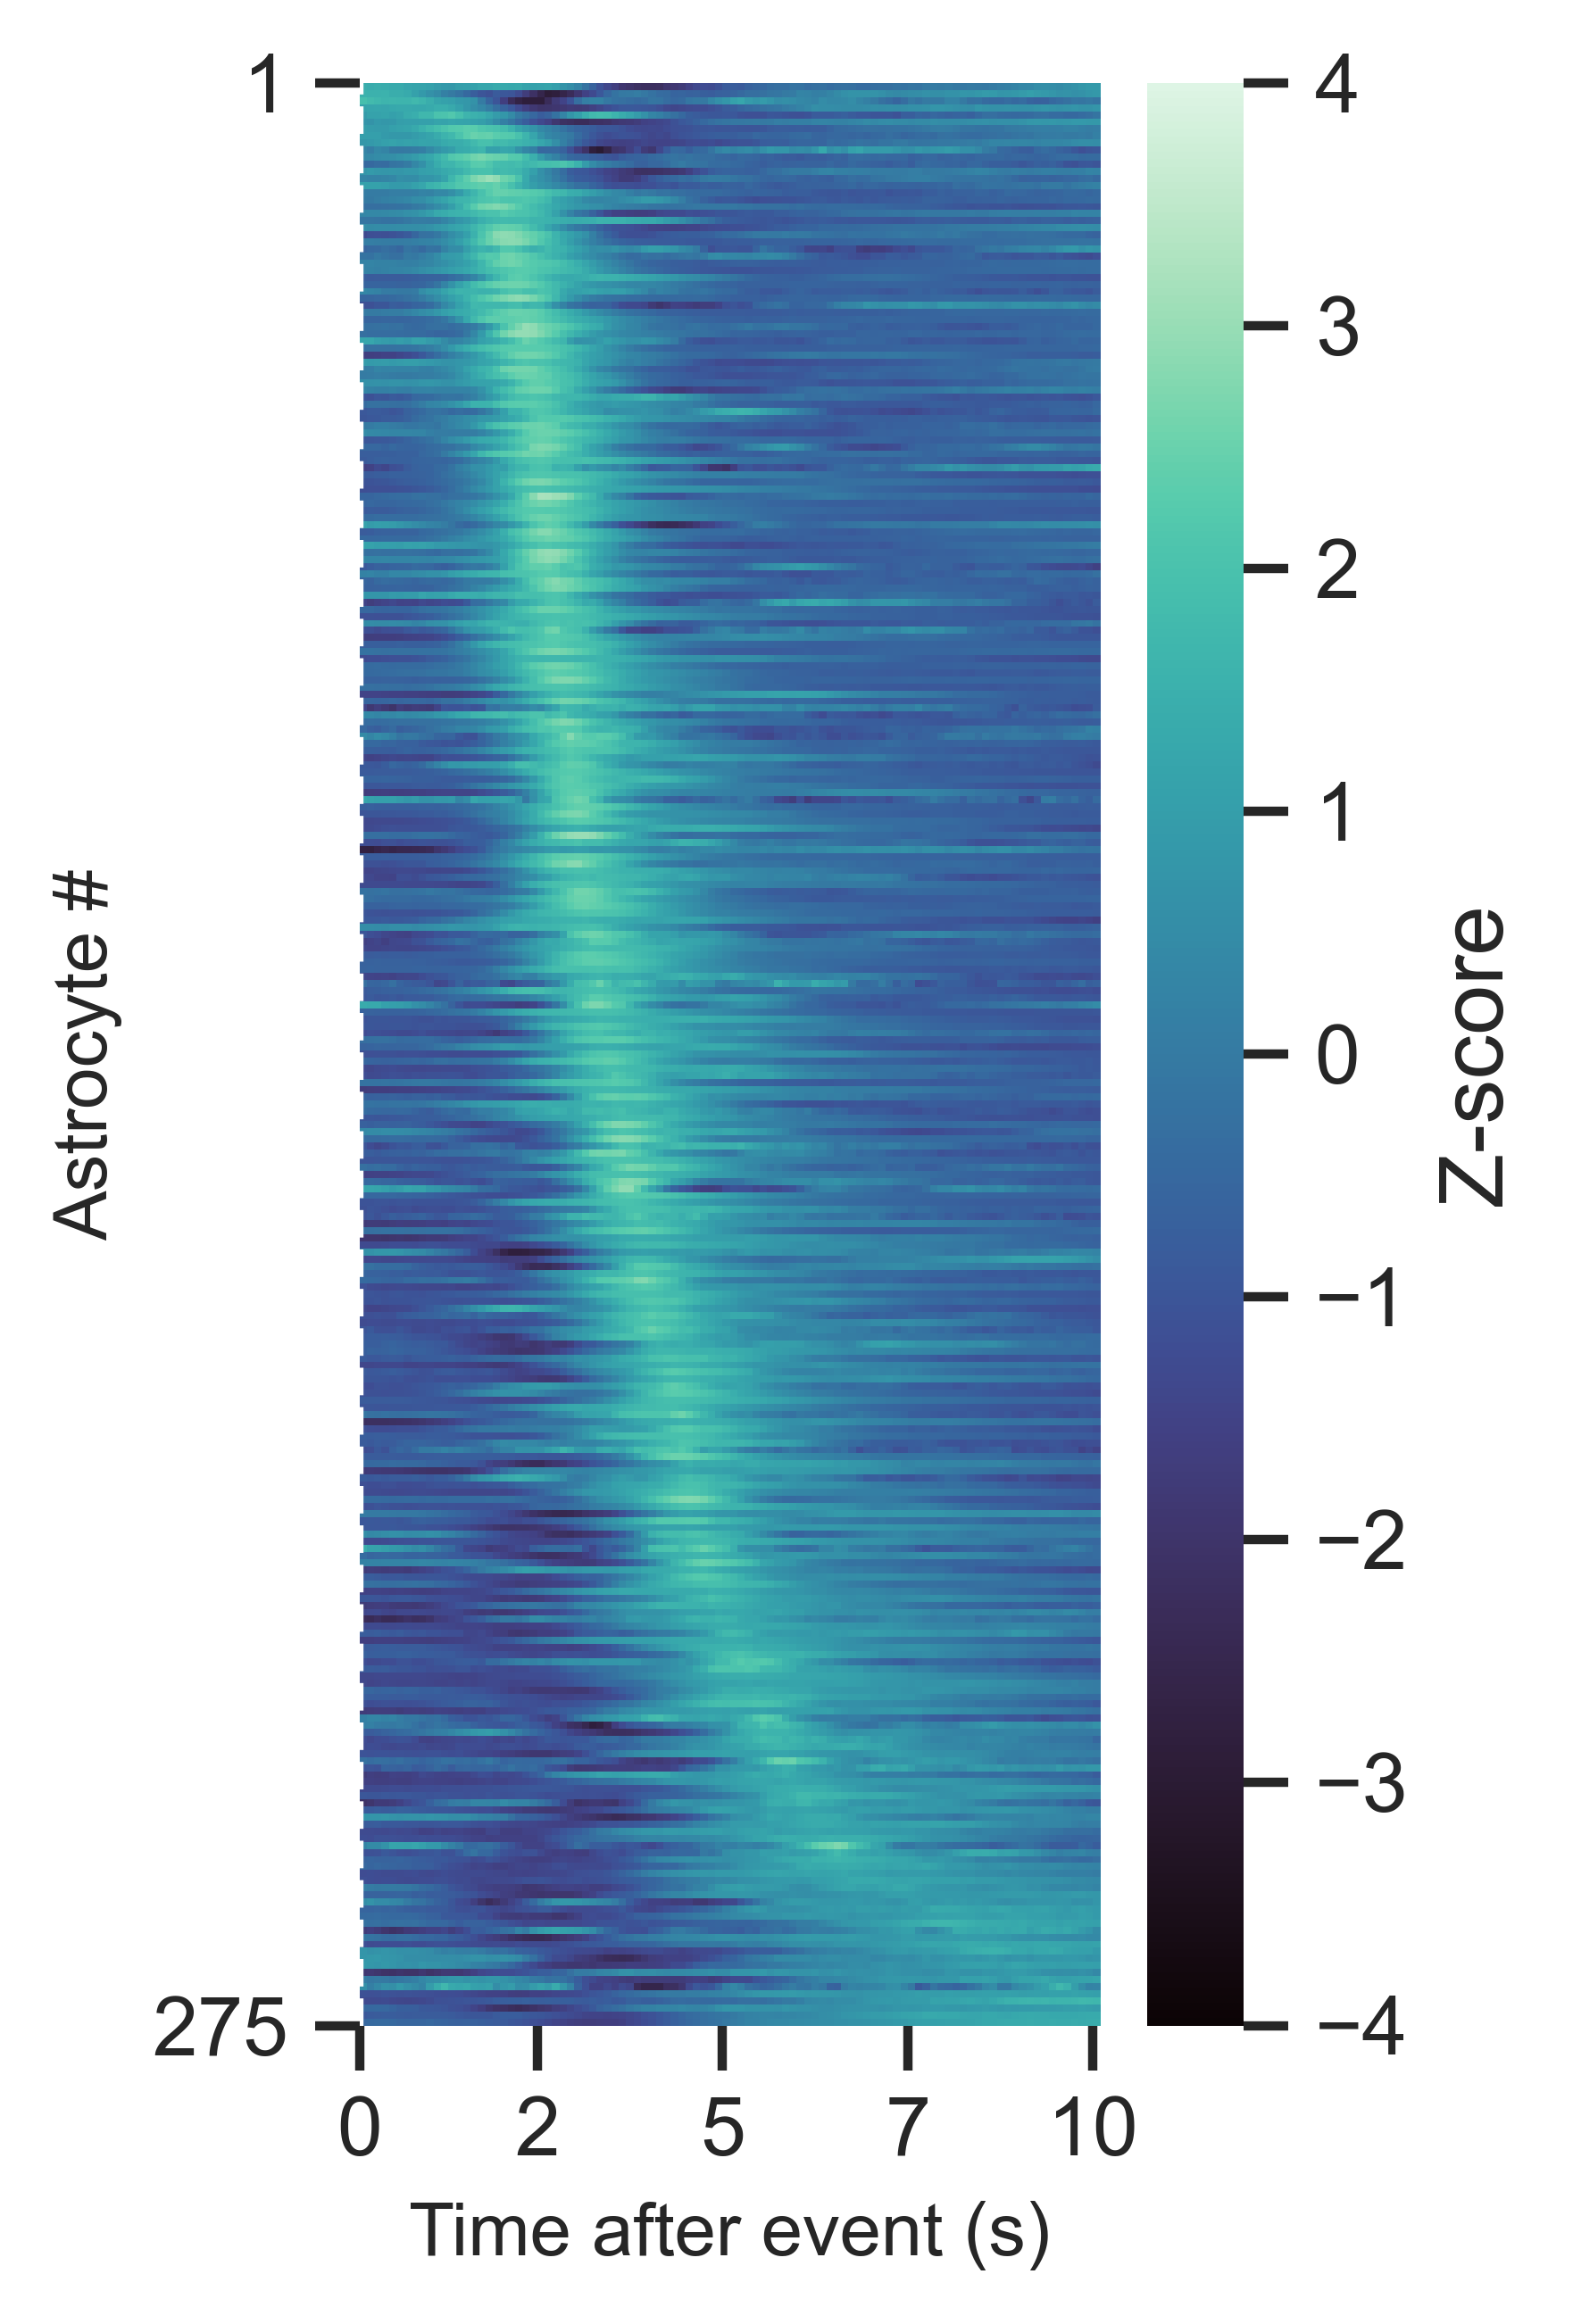

In [35]:
fig, ax, fp = run_post_event_heatmap(
    animal_id='astroM4',
    traces=astroM4,
    timestamps=collection_fc.animals['astroM4'].Timestamps[:astroM4.shape[0]].to_numpy().squeeze(),
    events=[120, 180, 240, 300],   # event times in seconds
    window=10,
    vmin=-4, vmax=4,
        save_path_prefix='/Users/suthardr/Desktop/Revision/'

)


In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.patches import Rectangle
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import seaborn as sns

def run_post_event_ridgeplot_pretty(
    animal_id,
    traces, timestamps, events,
    window=10,
    bin_size_sec=1.0,
    smooth_sigma=1,             # Gaussian smoothing (samples)
    normalize='perbin',         # 'perbin' (best) | 'z' | 'raw'
    order='desc',               # 'asc' (early bins on top) | 'desc' (late bins on top)
    cmap_name='viridis_r',
    ridge_height=1.0,           # vertical scale of ridges
    ridge_gap=0.30,             # vertical gap between ridges
    outline_alpha=0.9,
    save_path_prefix=None
):
    """
    Pretty ridge plot: each ridge is the mean trace of cells whose PEAK (by z) falls in that 1-s bin.
    - All panels in seconds.
    - Clean labels, minimal clutter, optional per-bin normalization for comparable shapes.
    """

    # ---------- style ----------
    sns.set_theme(context='paper', style='ticks', font='Arial')
    plt.rcParams.update({
        'figure.dpi': 600, 'savefig.dpi': 600,
        'axes.linewidth': 0.8, 'font.size': 8,
        'xtick.major.width': 0.8, 'ytick.major.width': 0.8
    })

    # ---------- shape to (N x T) ----------
    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    # ---------- sampling grid ----------
    dt = float(np.median(np.diff(timestamps)))
    fs = 1.0 / dt
    n_points = int(np.round(window * fs))
    post_t = np.linspace(0, window, n_points, endpoint=False)

    def post_event_slice(sig, e):
        t_win = e + post_t
        if t_win[-1] > timestamps[-1]: return None
        return np.interp(t_win, timestamps, sig)

    # mean post-event trace per cell
    curves = []
    for sig in data:
        evs = [post_event_slice(sig, e) for e in events]
        evs = [c for c in evs if c is not None]
        curves.append(np.nanmean(np.vstack(evs), axis=0) if evs else np.full(n_points, np.nan))
    eta = np.vstack(curves)  # (N x T)

    # choose signal for peak detection (z is robust)
    z = stats.zscore(eta, axis=1, nan_policy='omit'); z = np.nan_to_num(z, nan=0.0)
    peak_idx = np.argmax(z, axis=1)
    peak_time = post_t[peak_idx]

    # bins
    edges = np.arange(0, window + 1e-9, bin_size_sec)
    if edges[-1] < window: edges = np.append(edges, window)

    # what to plot in ridges
    if normalize == 'z':
        base = z
    elif normalize == 'raw':
        base = eta
    elif normalize == 'perbin':
        base = eta.copy()
    else:
        raise ValueError("normalize must be 'perbin', 'z', or 'raw'")

    # compute ridge means per bin
    bin_means, bin_labels, bin_colors = [], [], []
    cmap = cm.get_cmap(cmap_name); norm = colors.Normalize(vmin=0, vmax=window)
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i+1]
        members = np.where((peak_time >= lo) & (peak_time < hi))[0]
        if members.size == 0:
            bin_means.append(None); bin_labels.append(f"{int(lo)}–{int(hi)} s (n=0)")
            bin_colors.append(cmap(norm((lo+hi)/2))); continue
        m = np.nanmean(base[members, :], axis=0)
        if smooth_sigma > 0: m = gaussian_filter1d(m, sigma=smooth_sigma)
        if normalize == 'perbin':
            p2 = np.nanpercentile(np.abs(m), 98) or 1.0
            m = (m / p2) * ridge_height
        elif normalize == 'z':
            # already z; scale to ridge_height for consistent visual height
            p2 = np.nanpercentile(np.abs(m), 98) or 1.0
            m = (m / p2) * ridge_height
        # raw: keep amplitude as is, but soft-scale to avoid overlap
        bin_means.append(m)
        bin_labels.append(f"{int(lo)}–{int(hi)} s (n={members.size})")
        bin_colors.append(cmap(norm((lo+hi)/2)))

    # order bins
    idx_order = range(len(bin_means))
    if order == 'desc':
        idx_order = list(idx_order)[::-1]  # later bins at top

    # ---------- plot ----------
    # compute vertical offsets
    offsets = np.cumsum([0] + [ridge_height + ridge_gap for _ in range(len(bin_means)-1)])
    offsets = np.array(offsets)
    if order == 'desc': offsets = offsets  # already top-to-bottom mapping via loop

    fig, ax = plt.subplots(figsize=(5.0, 6.2))

    # draw ridges
    plotted = 0
    for k, i in enumerate(idx_order):
        m = bin_means[i]; color = bin_colors[i]
        if m is None: continue
        y0 = offsets[k]
        ax.fill_between(post_t, y0, y0 + m, color=color, alpha=0.70, linewidth=0)
        ax.plot(post_t, y0 + m, color=color, lw=1.0, alpha=outline_alpha)
        plotted += 1

    # pretty axes
    ax.set_xlim(0, window)
    ax.set_xlabel('Time after event (s)')
    # y ticks: a few labeled bands, not all
    if plotted > 0:
        tick_idx = np.linspace(0, plotted-1, min(plotted, 6)).astype(int)
        ax.set_yticks(offsets[tick_idx])
        ax.set_yticklabels([bin_labels[idx_order[j]] for j in tick_idx])
    ax.axvline(0, color='0.4', ls='--', lw=0.8)
    ax.margins(x=0)
    sns.despine(ax=ax)
    plt.tight_layout()

    # tiny time-gradient legend bar
    cax = ax.inset_axes([0.73, 0.06, 0.22, 0.02])  # [x, y, w, h] in axes coords
    grad = np.linspace(0, 1, 256)[None, :]
    cax.imshow(grad, aspect='auto', cmap=cmap, origin='lower',
               extent=[0, window, 0, 1])
    cax.set_xticks([0, window]); cax.set_xticklabels(['early', 'late'], fontsize=6)
    cax.set_yticks([]); cax.set_title('peak time', fontsize=6, pad=2)
    for spine in ['top','right','left','bottom']: cax.spines[spine].set_visible(False)

    out_path = None
    if save_path_prefix:
        out_path = f"{save_path_prefix.rstrip('/')}_{animal_id}_ridge_pretty_w{int(window)}s.svg"
        fig.savefig(out_path, bbox_inches='tight')
    return fig, ax, out_path


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_88849/1104258556.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name); norm = colors.Normalize(vmin=0, vmax=window)


Saved to: /Users/suthardr/Desktop/Revision_astroM4_ridge_pretty_w10s.svg


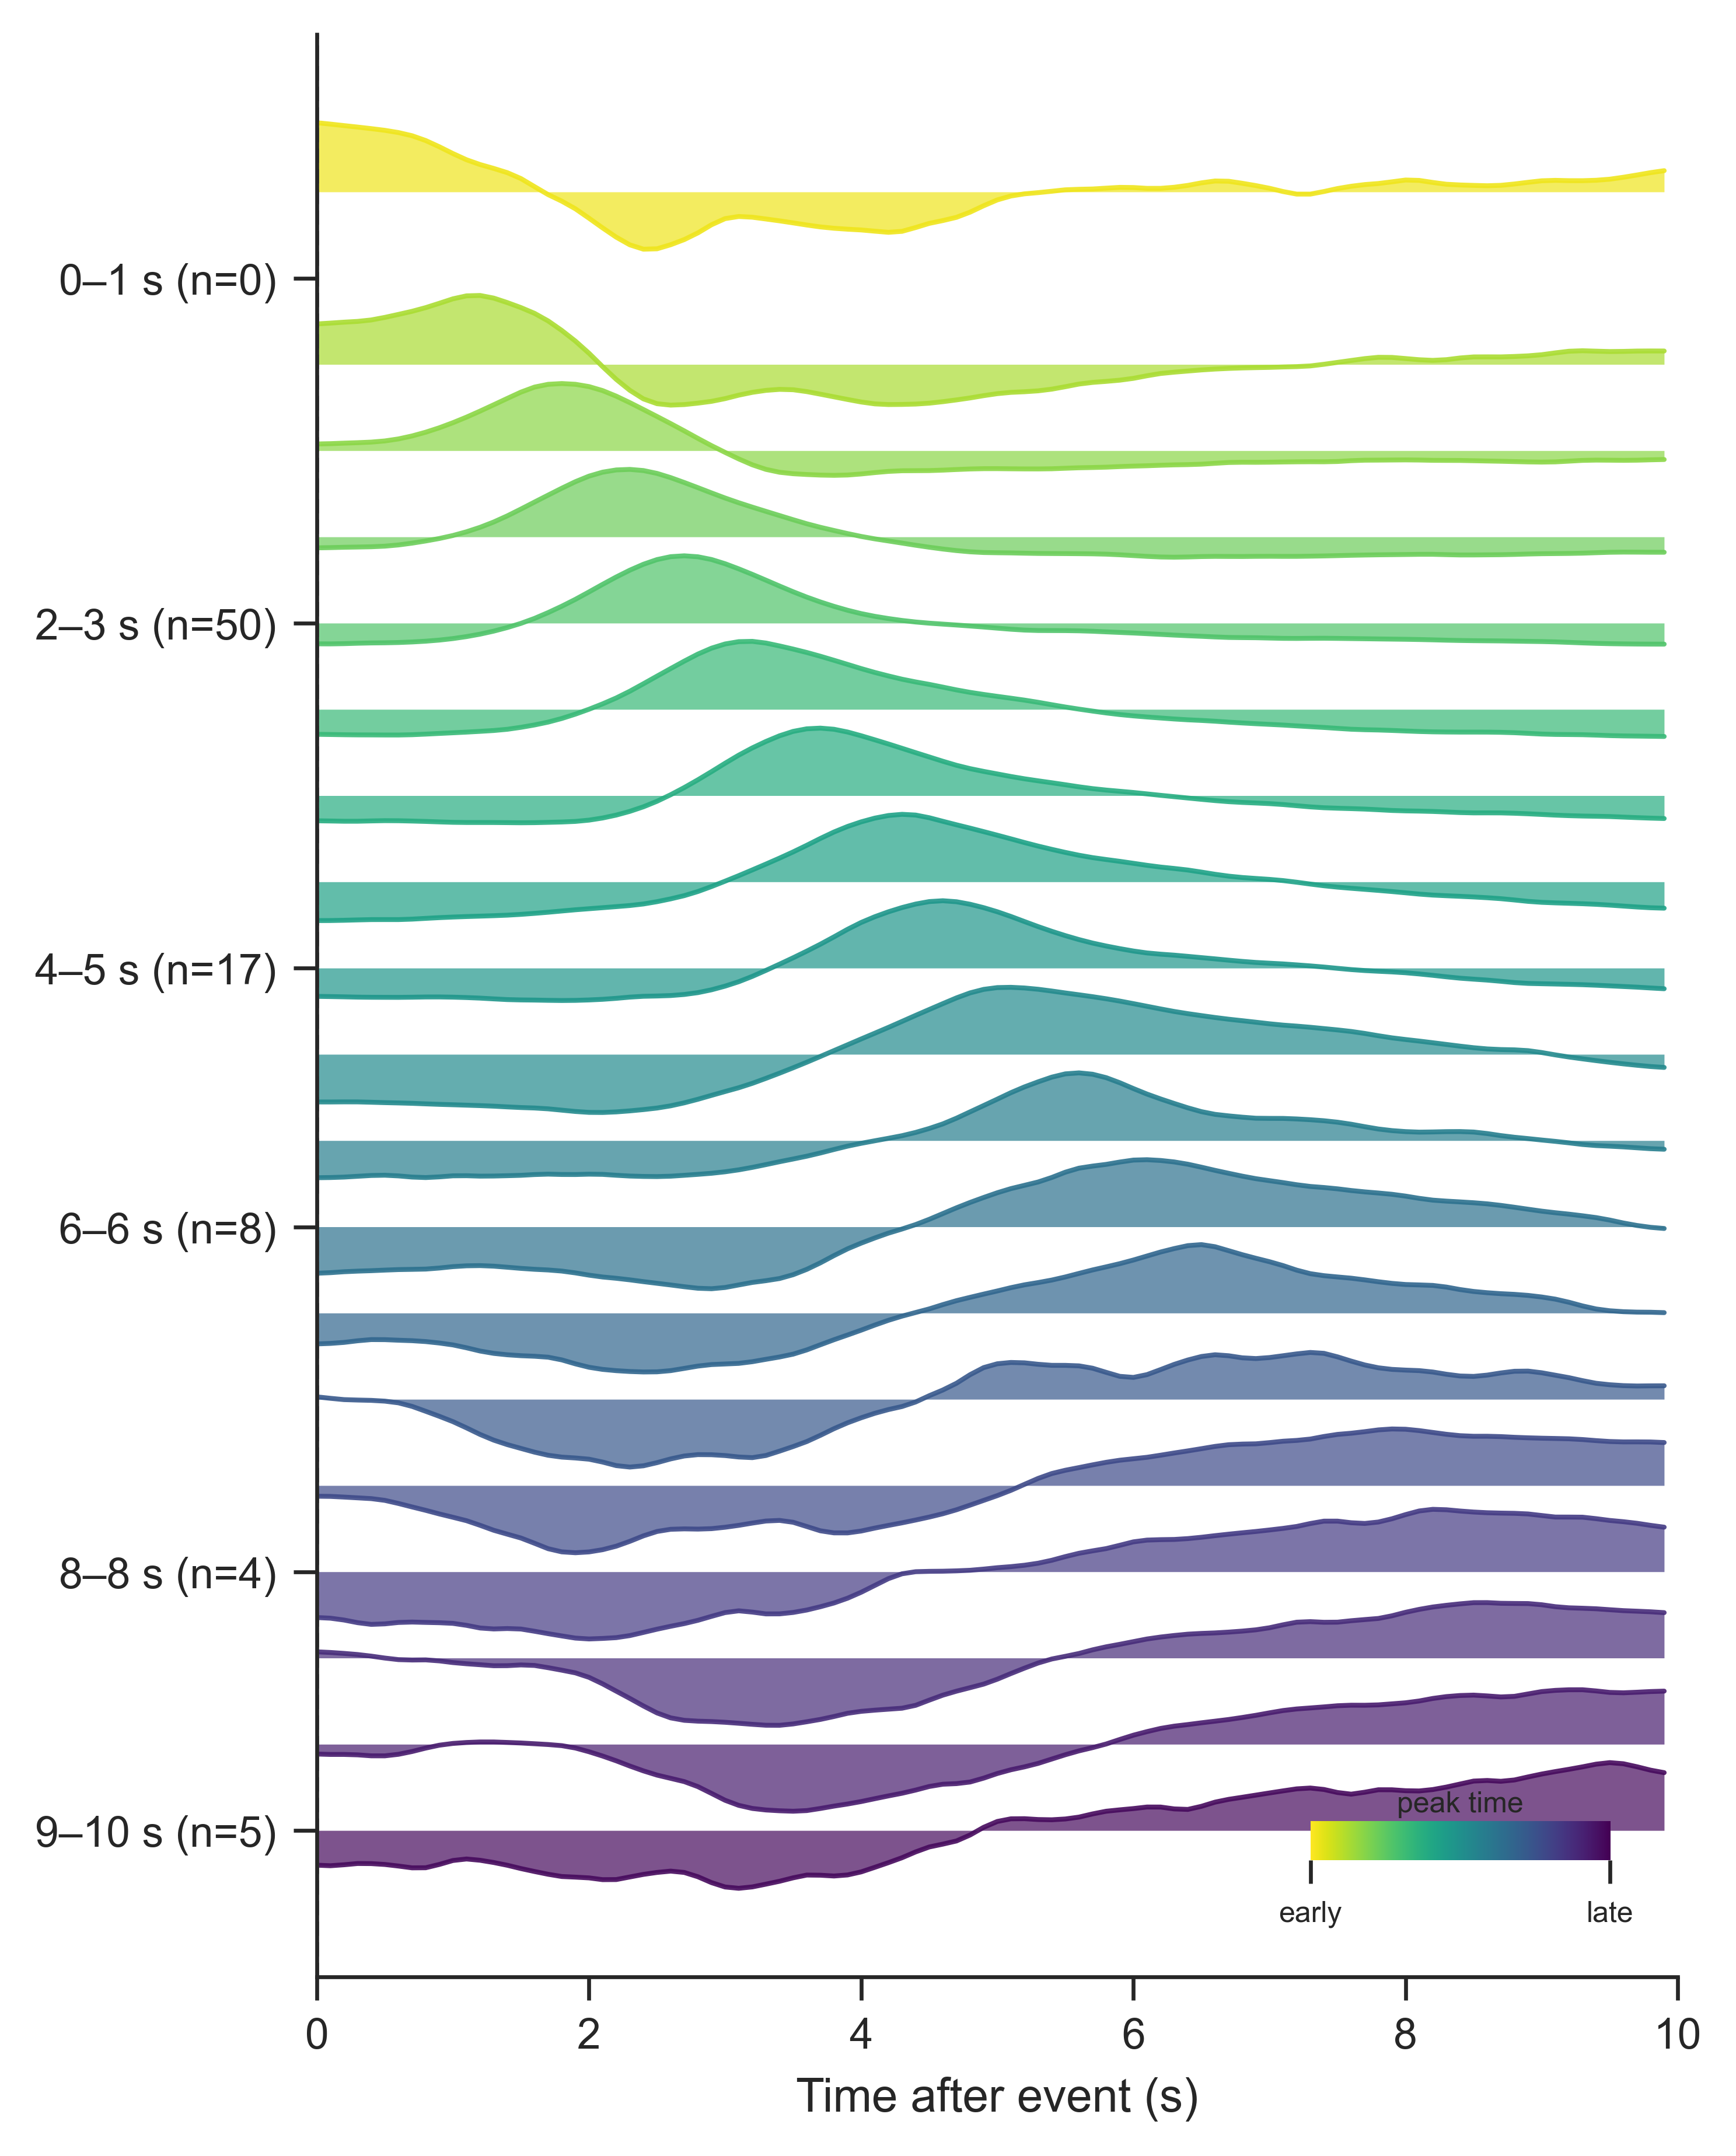

In [88]:
fig, ax, fp = run_post_event_ridgeplot_pretty(
    animal_id='astroM4',
    traces=astroM4,
    timestamps=collection_fc.animals['astroM4'].Timestamps[:astroM4.shape[0]].to_numpy().squeeze(),
    events=[120, 180, 240, 300],
    window=10,
    bin_size_sec=0.5,
    smooth_sigma=1,
    normalize='z',          # great for comparing ridge shapes
    order='desc',                # late peak bins on top
    ridge_gap=0.30,
    save_path_prefix='/Users/suthardr/Desktop/Revision/'
)
print("Saved to:", fp)


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_88849/2036128545.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


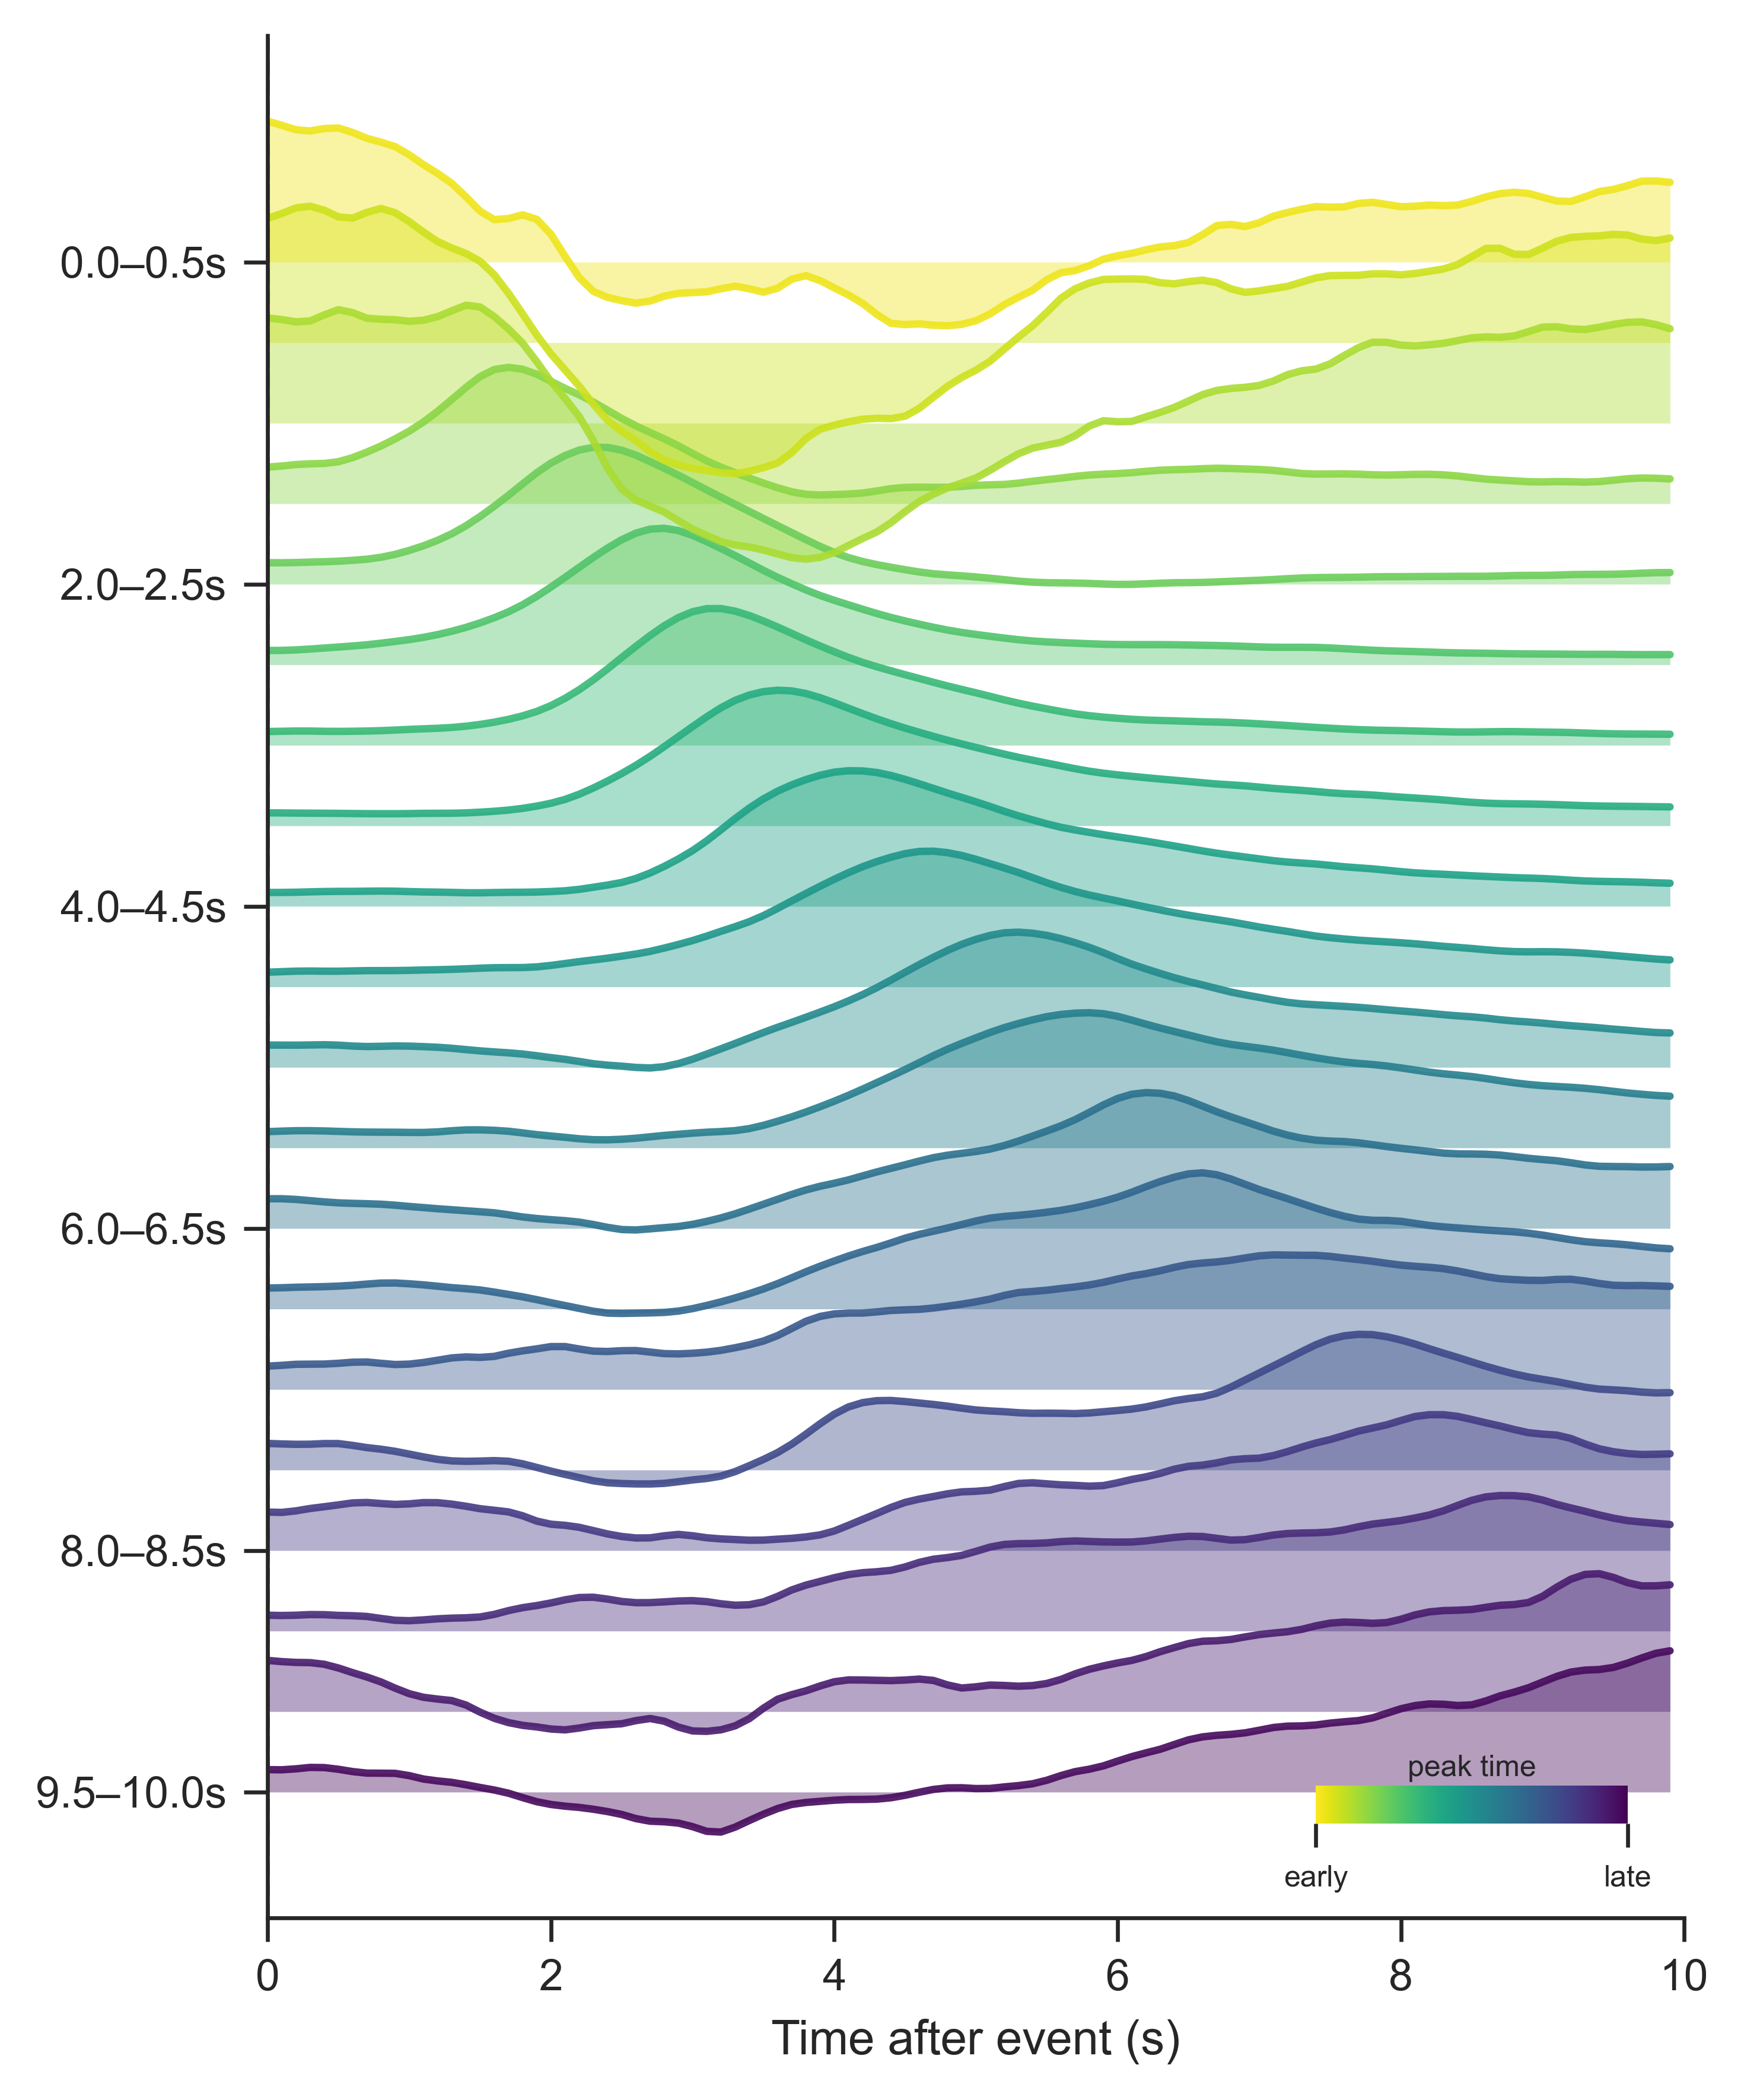

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import seaborn as sns

def run_post_event_ridgeplot_overlap(
    animal_id,
    traces, timestamps, events,
    window=10,
    bin_size_sec=1.0,
    smooth_sigma=1.2,
    normalize='perbin',          # 'perbin' or 'z' or 'raw'
    order='desc',                # late bins on top
    cmap_name='viridis_r',
    ridge_height=1.0,
    ridge_gap=-0.2,              # slight overlap between ridges
    alpha_fill=0.55,
    alpha_outline=0.9,
    save_path_prefix=None
):
    """Ridge plot with smooth, transparent overlapping ridges."""

    sns.set_theme(context='paper', style='ticks', font='Arial')
    plt.rcParams.update({
        'figure.dpi': 600, 'savefig.dpi': 600,
        'axes.linewidth': 0.8, 'font.size': 10,
        'xtick.major.width': 0.8, 'ytick.major.width': 0.8
    })

    # --- reshape to (N x T) ---
    data = traces.T if traces.shape[0] == timestamps.shape[0] else traces

    # --- sample grid ---
    dt = float(np.median(np.diff(timestamps)))
    fs = 1.0 / dt
    n_points = int(np.round(window * fs))
    post_t = np.linspace(0, window, n_points, endpoint=False)

    def post_event_slice(sig, e):
        t_win = e + post_t
        if t_win[-1] > timestamps[-1]: return None
        return np.interp(t_win, timestamps, sig)

    # average per cell
    curves = []
    for sig in data:
        evs = [post_event_slice(sig, e) for e in events]
        evs = [c for c in evs if c is not None]
        curves.append(np.nanmean(np.vstack(evs), axis=0) if evs else np.full(n_points, np.nan))
    eta = np.vstack(curves)

    # z-score for peak detection
    z = stats.zscore(eta, axis=1, nan_policy='omit')
    z = np.nan_to_num(z, nan=0.0)
    peak_idx = np.argmax(z, axis=1)
    peak_time = post_t[peak_idx]

    # bin edges
    edges = np.arange(0, window + 1e-9, bin_size_sec)
    if edges[-1] < window: edges = np.append(edges, window)

    # which data to plot
    if normalize == 'z': base = z
    elif normalize == 'raw': base = eta
    else: base = eta.copy()  # 'perbin'

    cmap = cm.get_cmap(cmap_name)
    norm = colors.Normalize(vmin=0, vmax=window)
    bin_means, bin_labels, bin_colors = [], [], []

    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i+1]
        members = np.where((peak_time >= lo) & (peak_time < hi))[0]
        if len(members) == 0:
            bin_means.append(None)
            bin_labels.append(f"{lo:.0f}–{hi:.0f}s")
            bin_colors.append(cmap(norm((lo+hi)/2)))
            continue
        m = np.nanmean(base[members, :], axis=0)
        if smooth_sigma > 0:
            m = gaussian_filter1d(m, sigma=smooth_sigma)
        if normalize == 'perbin':
            p2 = np.nanpercentile(np.abs(m), 98) or 1.0
            m = (m / p2) * ridge_height
        elif normalize == 'z':
            p2 = np.nanpercentile(np.abs(m), 98) or 1.0
            m = (m / p2) * ridge_height
        bin_means.append(m)
        bin_labels.append(f"{(lo)}–{(hi)}s")
        bin_colors.append(cmap(norm((lo+hi)/2)))

    # order bins (desc = later at top)
    idx_order = list(range(len(bin_means)))
    if order == 'desc':
        idx_order = idx_order[::-1]

    # --- plot ---
    offsets = np.cumsum([0] + [ridge_height + ridge_gap for _ in range(len(bin_means)-1)])
    fig, ax = plt.subplots(figsize=(5, 6))
    for k, i in enumerate(idx_order):
        m = bin_means[i]
        if m is None: continue
        color = bin_colors[i]
        y0 = offsets[k]
        ax.fill_between(post_t, y0, y0 + m, color=color, alpha=alpha_fill, linewidth=0)
        ax.plot(post_t, y0 + m, color=color, lw=1.5, alpha=alpha_outline)

    # styling
    ax.set_xlim(0, window)
    ax.set_xlabel('Time after event (s)')
    tick_idx = np.linspace(0, len(idx_order)-1, min(len(idx_order), 6)).astype(int)
    ax.set_yticks(offsets[tick_idx])
    ax.set_yticklabels([bin_labels[idx_order[j]] for j in tick_idx])
    ax.axvline(0, color='0.4', ls='--', lw=0.8)
    sns.despine(ax=ax)
    plt.tight_layout()

    # gradient bar legend
    cax = ax.inset_axes([0.74, 0.05, 0.22, 0.02])
    grad = np.linspace(0, 1, 256)[None, :]
    cax.imshow(grad, aspect='auto', cmap=cmap, origin='lower', extent=[0, window, 0, 1])
    cax.set_xticks([0, window])
    cax.set_xticklabels(['early', 'late'], fontsize=6)
    cax.set_yticks([])
    cax.set_title('peak time', fontsize=6, pad=2)
    for s in cax.spines.values():
        s.set_visible(False)

    out_path = None
    if save_path_prefix:
        out_path = f"{save_path_prefix.rstrip('/')}_{animal_id}_ridge_overlap_w{int(window)}s.svg"
        fig.savefig(out_path, bbox_inches='tight')
    return fig, ax, out_path
fig, ax, fp = run_post_event_ridgeplot_overlap(
    animal_id='astroM5',
    traces=astroM5,
    timestamps=collection_fc.animals['astroM3'].Timestamps[:astroM3.shape[0]].to_numpy().squeeze(),
    events=[120, 180, 240, 300],
    window=10,
    bin_size_sec=0.5,
    smooth_sigma=1,
    normalize='perbin',
    ridge_height=1.0,
    ridge_gap=-0.4,
    alpha_fill=0.40,
    cmap_name='viridis_r',
    save_path_prefix='/Users/suthardr/Desktop/Revision/'
)


In [8]:
def run_cross_validated_analysis(
    animal_id, traces, timestamps, save_path_prefix,
    do_shuffle=True, n_shuffles=10000, seed=None, two_sided=True
):
    # ---------------- helpers ----------------
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x); y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            if r_obs >= 0:
                p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1)
            else:
                p_emp = (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    # ---------------- analysis ----------------
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})

    # Compute ETA for shocks 1&3 and 2&4
    whole_eta_13, time_13 = onep.eta_individual_cells(traces.T, timestamps, [[120, 240]], window=28)
    whole_eta_24, time_24 = onep.eta_individual_cells(traces.T, timestamps, [[180, 300]], window=28)

    # Z-score starting at 140
    adjusted_whole_eta_1_3 = stats.zscore(whole_eta_13[:, 140:], axis=1)
    adjusted_whole_eta_2_4 = stats.zscore(whole_eta_24[:, 140:], axis=1)
    time_1_3 = time_13[140:]

    # Sort arrays by max
    sorted_array_1, idxs_13 = onep.maxsort(adjusted_whole_eta_1_3)
    sorted_array_2, idxs_24 = onep.maxsort(adjusted_whole_eta_2_4)

    # y-ticks for heatmaps
    first_last = [0, len(adjusted_whole_eta_1_3)]

    # --- Heatmaps ---
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.heatmap(adjusted_whole_eta_1_3[idxs_13], ax=ax1, cmap='mako', cbar=False,
                xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax1.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax1.set_yticks(first_last)
    ax1.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax1.set_title('Odd Shocks [1&3]', fontsize=10, pad=10)
    ax1.set_ylabel('Astrocyte #', fontsize=10)
    ax1.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax1, left=True, bottom=True)

    sns.heatmap(adjusted_whole_eta_1_3[idxs_24], ax=ax2, cmap='mako', cbar=True,
                cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax2.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax2.set_yticks(first_last)
    ax2.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax2.set_title('Odd Shocks [1&3] sorted by Even Shocks [2&4]', fontsize=10, pad=10)
    ax2.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax2, left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # --- Argmaxes ---
    max_idxs_1_3 = np.argmax(sorted_array_1, axis=1)
    argmax_1_3 = time_1_3[max_idxs_1_3]

    odd_sorted_even = adjusted_whole_eta_1_3[idxs_24]
    sorted_idx = np.argmax(odd_sorted_even, axis=1)
    argmax_1_3_sorted_2_4 = time_1_3[sorted_idx]

    # --- Spearman correlation ---
    rho_s, p_s = stats.spearmanr(argmax_1_3, argmax_1_3_sorted_2_4)
    print(f"{animal_id} - Spearman rho: {rho_s:.4f}, p-value: {p_s:.4e}")

    # --- Shuffle control (optional) ---
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_1_3, argmax_1_3_sorted_2_4,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        print(f"{animal_id} - shuffle null: mean={shres['null_mean']:.4f}, "
              f"sd={shres['null_std']:.4f}, empirical p={shres['p_empirical']:.4g}, "
              f"z={shres['z_obs_vs_null']:.2f}")
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # --- Regression data (clean) ---
    df = pd.DataFrame({
        'Argmax Odds sorted Odds': argmax_1_3,
        'Argmax Odds sorted Evens': argmax_1_3_sorted_2_4
    })
    x_name = 'Argmax Odds sorted Odds'
    y_name = 'Argmax Odds sorted Evens'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()
    X = sm.add_constant(x)

    # --- Fit RLM ---
    model = sm.RLM(y, X).fit()

    # ---- R^2 variants ----
    y_pred = np.asarray(model.fittedvalues)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # guard for degenerate correlation
    try:
        r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
    except Exception:
        r2_corr = np.nan

    rho_rlm = model.model.M.rho
    scale = getattr(model, "scale", 1.0) or 1.0
    resid_fit_scaled = (y - y_pred) / scale
    resid_null_scaled = (y - float(np.mean(y))) / scale
    loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
    loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
    r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

    # ---- Extract flattened params ----
    beta  = np.asarray(model.params)        # [intercept, slope]
    pvals = np.asarray(model.pvalues)       # [p_intercept, p_slope]
    intercept = float(beta[0]) if beta.size > 0 else np.nan
    slope     = float(beta[1]) if beta.size > 1 else np.nan
    p_value_bias  = float(pvals[0]) if pvals.size > 0 else np.nan
    p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

    # --- Plot: scatter + RLM line + 95% CI (bootstrap with fallback) ---
    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

    x_grid = np.linspace(x.min(), x.max(), 200)
    X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X_grid @ np.asarray(model.params)
    ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

    n_boot = 1000
    min_ok = 100
    rng = np.random.default_rng(12345)
    y_boot = np.full((n_boot, x_grid.size), np.nan, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, len(_df), size=len(_df))
        xb = x[idx]; yb = y[idx]
        Xb = sm.add_constant(xb)
        try:
            mb = sm.RLM(yb, Xb).fit()
            y_boot[b, :] = X_grid @ np.asarray(mb.params)
        except Exception:
            pass

    counts = np.sum(np.isfinite(y_boot), axis=0)
    lower = np.full_like(y_hat, np.nan)
    upper = np.full_like(y_hat, np.nan)
    ok = counts >= min_ok
    if np.any(ok):
        lower[ok] = np.nanpercentile(y_boot[:, ok], 2.5, axis=0)
        upper[ok] = np.nanpercentile(y_boot[:, ok], 97.5, axis=0)

    if np.any(~ok):
        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z = stats.norm.ppf(0.975)
        lower_analytic = y_hat - z * se_mean
        upper_analytic = y_hat + z * se_mean
        lower[~ok] = lower_analytic[~ok]
        upper[~ok] = upper_analytic[~ok]

    ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
    ax.set_xlabel('Argmax Odds Sorted Odds (s)', fontsize=10, fontname="Arial")
    ax.set_ylabel('Argmax Odds Sorted Evens (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 25)
    ax.set_xlim(0, 25)
    sns.despine(ax=ax)
    ax.legend(frameon=False)

    scatter_fp = f"{save_path_prefix}_scatter.svg"
    fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---- Return flattened summary ----
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }

In [39]:
# ===================== batch runner =====================

trace_lookup = {mouse: globals()[mouse] for mouse in mouse_ids}

all_results = []
save_dir = '/Users/ryansenne/Downloads'

for mouse in mouse_ids:
    print(f"Processing {mouse}...")
    traces = trace_lookup[mouse]
    timestamps = collection_fc.animals[mouse].Timestamps[:3303]
    res = run_cross_validated_analysis(
        animal_id=mouse,
        traces=traces,
        timestamps=timestamps,
        save_path_prefix=f"{save_dir}/FC_crossvalled_{mouse}"
    )
    all_results.append(res)

df_all_results = pd.DataFrame(all_results)

# put 'animal' first if present
if 'animal' in df_all_results.columns:
    cols = ['animal'] + [c for c in df_all_results.columns if c != 'animal']
    df_all_results = df_all_results[cols]

print(df_all_results)
df_all_results.to_csv(f'{save_dir}/crossval_summary_results.csv', index=False)
print(f"Saved: {save_dir}/crossval_summary_results.csv")

Processing astroF3...
astroF3 - Spearman rho: 0.5106, p-value: 1.1733e-09
astroF3 - shuffle null: mean=-0.0002, sd=0.0896, empirical p=9.999e-05, z=5.70
Processing astroF5...
astroF5 - Spearman rho: 0.5812, p-value: 5.1628e-19
astroF5 - shuffle null: mean=0.0019, sd=0.0710, empirical p=9.999e-05, z=8.16
Processing astroF6...
astroF6 - Spearman rho: 0.7504, p-value: 8.0862e-36
astroF6 - shuffle null: mean=-0.0004, sd=0.0723, empirical p=9.999e-05, z=10.39
Processing astroF7...
astroF7 - Spearman rho: 0.7853, p-value: 1.9744e-28
astroF7 - shuffle null: mean=0.0007, sd=0.0884, empirical p=9.999e-05, z=8.87
Processing astroF8...
astroF8 - Spearman rho: 0.4951, p-value: 1.6180e-20
astroF8 - shuffle null: mean=-0.0005, sd=0.0573, empirical p=9.999e-05, z=8.66
Processing astroF9...
astroF9 - Spearman rho: 0.6760, p-value: 3.3213e-40
astroF9 - shuffle null: mean=0.0004, sd=0.0587, empirical p=9.999e-05, z=11.51
Processing astroF10...
astroF10 - Spearman rho: 0.7284, p-value: 5.1699e-35
astroF1

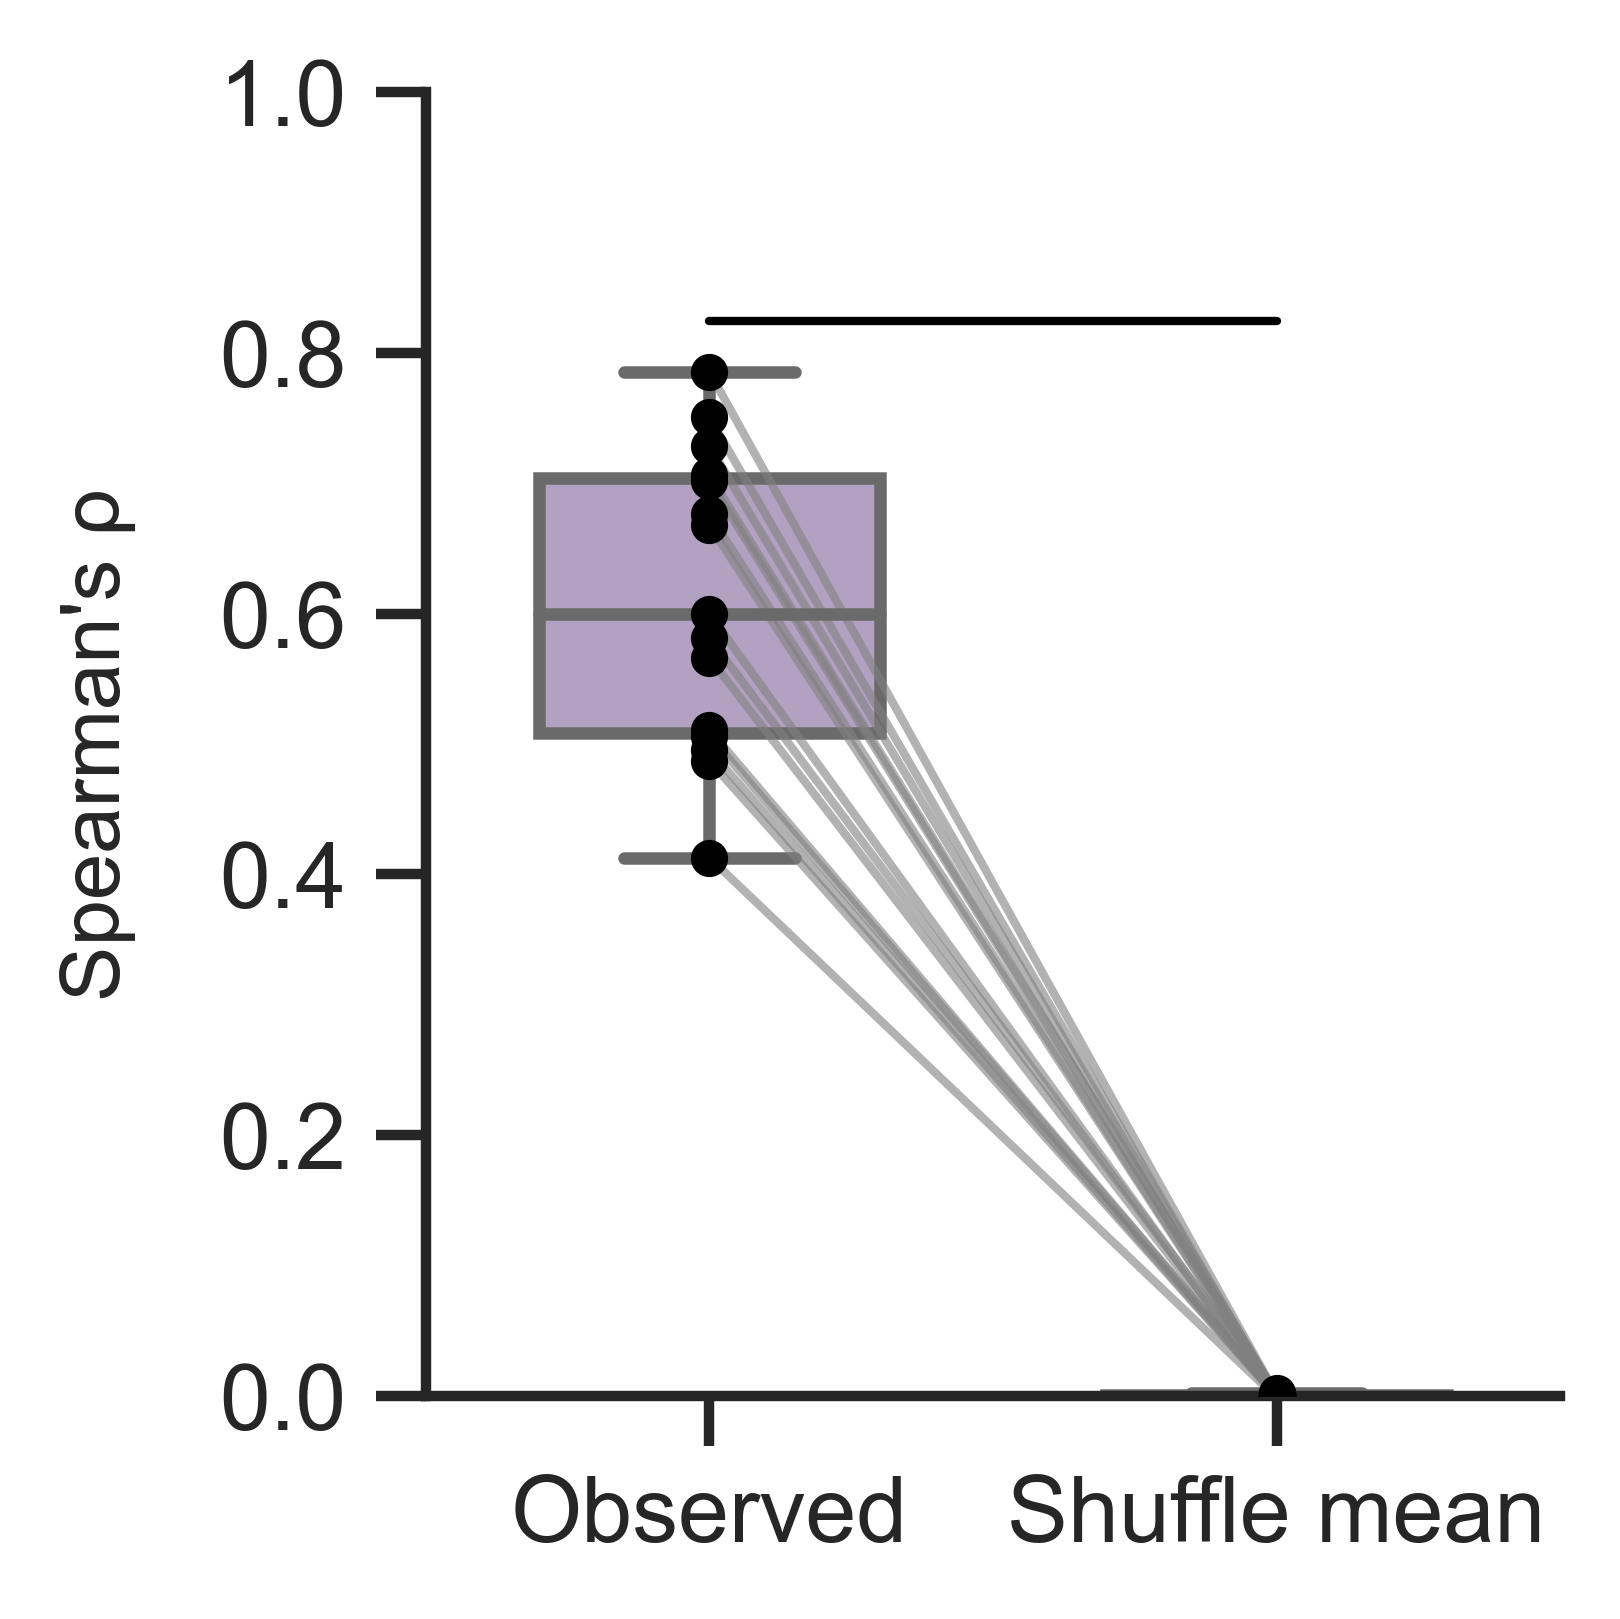

In [40]:
from scipy.stats import ttest_rel

def plot_spearman_rho_paired(
    df,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal",
    title="",
    save_path=None
):
    """
    Draws side-by-side boxplots of observed Spearman rho vs shuffle-mean rho,
    overlays paired points per animal connected by line segments,
    and annotates a paired t-test.

    Expects df to have columns: [id_col, obs_col, null_col].
    """
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial', 'figure.figsize': (3.5, 3.5)})
    sns.set(style="ticks", font="Arial")

    # Keep rows with both values present
    d = df[[id_col, obs_col, null_col]].dropna().copy()
    if d.empty:
        raise ValueError("No rows with both observed and shuffle mean rhos present.")

    # Paired t-test
    tstat, pval = ttest_rel(d[obs_col], d[null_col])

    # Long form for plotting
    long = d.melt(
        id_vars=id_col,
        value_vars=[obs_col, null_col],
        var_name="condition",
        value_name="rho"
    )
    name_map = {obs_col: "Observed", null_col: "Shuffle mean"}
    long["condition"] = long["condition"].map(name_map)

    order = ["Observed", "Shuffle mean"]  # left→right
    palette = {"Observed": "#B39BC8", "Shuffle mean": "#C9D6DF"}  # keep your original purple

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    # Boxplots (background)
    sns.boxplot(
        data=long, x="condition", y="rho",
        order=order, palette=palette, ax=ax,
        width=0.6, showfliers=False
    )

    # Connect each animal’s pair and plot points
    x_pos = {cond: i for i, cond in enumerate(order)}
    for animal, grp in long.groupby(id_col):
        if set(order).issubset(set(grp["condition"])):
            y0 = grp.loc[grp["condition"] == "Shuffle mean", "rho"].values[0]
            y1 = grp.loc[grp["condition"] == "Observed", "rho"].values[0]
            ax.plot(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                color="gray", alpha=0.6, linewidth=1, zorder=2
            )
            ax.scatter(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                s=12, color="black", zorder=3
            )

    # Axis labels, limits, title
    ax.set_ylabel("Spearman's ρ", fontsize=10, fontname='Arial', labelpad=10)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    ax.set_ylim(0, 1)

    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    # Significance bar + text
    y_max = long["rho"].max()
    y_min = long["rho"].min()
    span = max(1e-6, y_max - y_min)
    y_bar = y_max + 0.05 * span
    ax.plot([x_pos["Shuffle mean"], x_pos["Observed"]], [y_bar, y_bar], color="black", linewidth=1)

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (tstat, pval)

fig, ax, (t, p) = plot_spearman_rho_paired(
    df_all_results,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal"
)

plt.savefig('/Users/ryansenne/Downloads/FC_crossval_rho_paired.svg', dpi=600, bbox_inches='tight', format='svg')

In [8]:
from scipy.stats import ttest_1samp

rhos = df_all_results['spearman_rho']
t_stat, p_val = ttest_1samp(rhos, 0)

print(f"One-sample t-test against zero:")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")


One-sample t-test against zero:
t-statistic = 20.859, p-value = 0.0000
